# EDA - Logístico

Etapa destinada a exploração dos dados de entrega da base. Visamos responder as seguinte perguntas:

1. Como está o NPS geral da base?
2. Como está a operação de entrega?
3. Como a operação logística afeta o NPS?

# Setup e carga dos dados

Importar as bibliotecas necessárias e carregar a base após tratamento.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Caminho para a base de dados
    
data = '../data/processed/desafio_nps_fase_1_clean.csv'
df = pd.read_csv(data)

print(f'Dimensão da base: {df.shape[0]} linhas x {df.shape[1]} colunas')
df.head()

Dimensão da base: 2465 linhas x 19 colunas


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


# Classificação NPS x Distribuição na Base

O nps foi classificado em 3 grupos, conforme regra de negócio abaixo.

* Detratores (notas <= 6.5): clientes insatisfeitos.
* Neutros/Passivos (6.5 > notas <= 8.5): indiferentes.
* Promotores (notas > 8.5): satisfeitos, entusiamados e leais a marca.

Pela regra o nps é uma nota inteira. Devido a base conter informações em decimal, optamos por arredondar notas de até 6,5 para 6 (Detratores) e até 8,5 para 8 (Neutros). 

In [13]:
# Classificação da base original

df_classificado = df.copy()

df_classificado["classificacao_nps"] = pd.cut(
    df_classificado["nps_score"],
    bins=[-float("inf"), 6.5, 8.5, float("inf")],
    labels=["Detratores", "Passivos", "Promotores"]
)

df_classificado.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,classificacao_nps
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5,Passivos
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0,Detratores
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5,Detratores
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3,Detratores
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9,Detratores


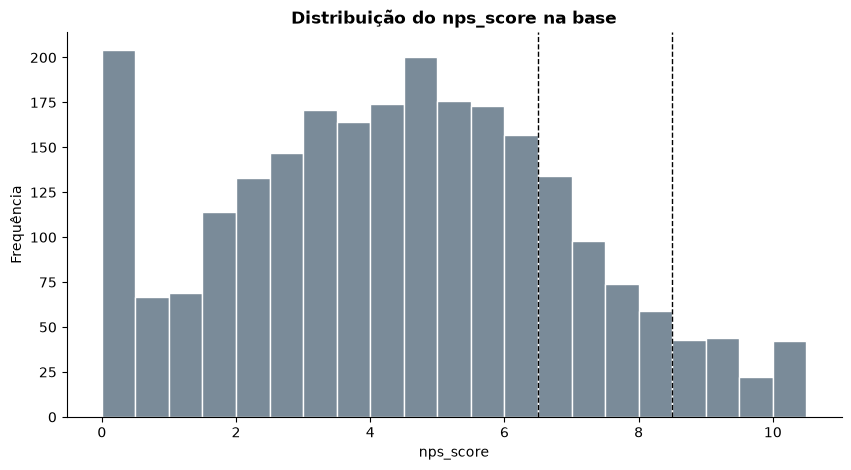

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df_classificado["nps_score"], bins=np.arange(0, 10.6, 0.5), edgecolor="white", color="#7A8B99")

# Fronteiras de classificação (bins do pd.cut)
for corte in (6.5, 8.5):
    plt.axvline(corte, color="black", linestyle="--", linewidth=1)

plt.title("Distribuição do nps_score na base", fontweight="bold")
plt.xlabel("Notas de nps_score")
plt.ylabel("Frequência")
sns.despine()
plt.show()

In [12]:
# Cálculo de KPIs da base

total = len(df_classificado)

# Distribuição de Tipo de Clientes por classificação
distribuicao_nps = (
    df_classificado["classificacao_nps"]
    .value_counts()
    .reindex(["Detratores", "Passivos", "Promotores"])
    .reset_index()
)

# % de Tipo de Clientes por classificação
distribuicao_nps.columns = ["classificacao_nps", "quantidade"]
distribuicao_nps["percentual"] = (
    distribuicao_nps["quantidade"] / total * 100
)

# Cálculo % de promotores na base
pct_promotores = distribuicao_nps.loc[
    distribuicao_nps["classificacao_nps"] == "Promotores", "percentual"
].iloc[0]

# Cálculo % de detratores na base
pct_detratores = distribuicao_nps.loc[
    distribuicao_nps["classificacao_nps"] == "Detratores", "percentual"
].iloc[0]

# Cálculo do NPS geral da base
nps_geral = pct_promotores - pct_detratores

# Apresenta os KPIs e a distribuição da base
print(f"Média de nps_score: {df_classificado['nps_score'].mean():.2f}")
print(f"NPS geral (% Promotores - % Detratores): {nps_geral:.1f}")
distribuicao_nps

Média de nps_score: 4.38
NPS geral (% Promotores - % Detratores): -74.3


,classificacao_nps,quantidade,percentual
0,Detratores,1975,80.121704
1,Passivos,346,14.036511
2,Promotores,144,5.841785


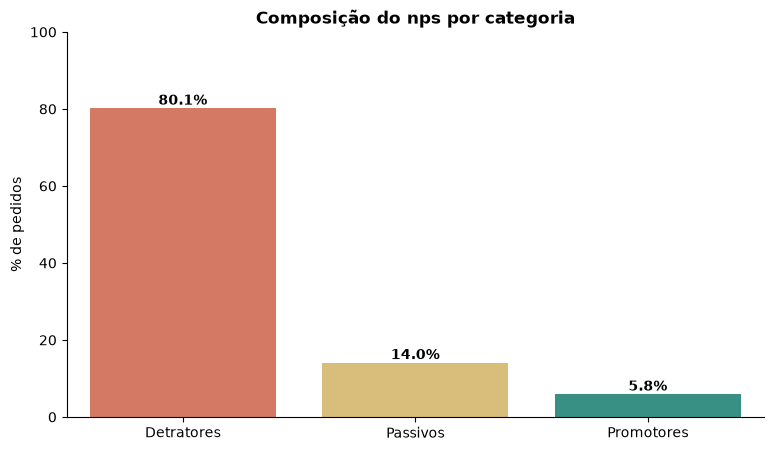

In [11]:
# Composição do nps por categoria

CORES_NPS = {
    "Detratores": "#E76F51",
    "Passivos": "#E9C46A",
    "Promotores": "#2A9D8F"
}

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=distribuicao_nps,
    x="classificacao_nps",
    y="percentual",
    hue="classificacao_nps",
    palette=CORES_NPS,
    legend=False
)

for i, linha in distribuicao_nps.iterrows():
    ax.text(
        i,
        linha["percentual"] + 1,
        f'{linha["percentual"]:.1f}%',
        ha="center",
        fontweight="bold"
    )

plt.title("Composição do nps por categoria", loc="center", fontweight="bold")
plt.xlabel("")
plt.ylabel("% de pedidos")
plt.ylim(0, 100)
sns.despine()
plt.show()

Conclusão:

A base é majoritariamente composta por Detratores, sendo 80% da base. Em vista disso, exploraremos a partir dos dados as possíveis relações que possam estar relacionadas a insatisfação do cliente.

# Como está a operação de entrega?

Validação da operação de entrega como possível relação a satisfação do cliente. Foram analisados:

* dias de atraso
* prazo/tempo de entrega
* frete
* tentativas de entrega

In [ ]:
# Define os principais KPIs de entrega para analisar
# Pedidos, Atraso, Tempo Médio, Frete, 
# Tentativas de Entrega e % de pedidos com 1+ dias de atraso

kpis_entrega = pd.DataFrame({
    "Indicador": [
        "Pedidos analisados",
        "Mediana de Atraso (dias)",
        "Mediana do Tempo de entrega (dias)",
        "Frete médio (R$)",
        "Tentativas médias de entrega",
        "% pedidos com 1+ dias de atraso"
    ],
    "Valor": [
        len(df),
        df["delivery_delay_days"].median().round(2),
        df["delivery_time_days"].median().round(2),
        df["freight_value"].mean().round(2),
        df["delivery_attempts"].mean().round(2),
        (df["delivery_delay_days"] >= 1).mean().round(2) * 100
    ]
})

kpis_entrega

,Indicador,Valor
0,Pedidos analisados,2465.00
1,Mediana de Atraso (dias),2.00
2,Mediana do Tempo de entrega (dias),8.00
3,Frete médio (R$),38.29
4,Tentativas médias de entrega,2.01
5,% pedidos com 1+ dias de atraso,89.00


89% dos clientes na base receberam o seu pedido atrasado. Além disso, boa parte dos atraso ocorre em 2 dias.

In [52]:
# Classificação de Atraso

df_classificado["faixa_atraso"] = pd.cut(
    df_classificado["delivery_delay_days"],
    bins=[-float("inf"), 0, 1, 2, float("inf")],
    labels=["No prazo", "1 dia", "2 dias", "3+ dias"]
)

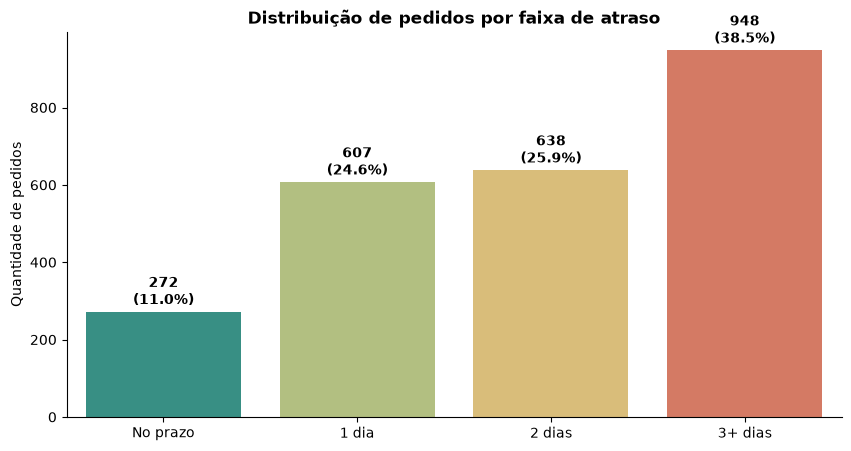

In [57]:
ORDEM_ATRASO = ["No prazo", "1 dia", "2 dias", "3+ dias"]

distribuicao_atraso = (
    df_classificado["faixa_atraso"]
    .value_counts()
    .reindex(ORDEM_ATRASO)
    .reset_index()
)

distribuicao_atraso.columns = ["faixa_atraso", "quantidade"]
distribuicao_atraso["percentual"] = (
    distribuicao_atraso["quantidade"] / total * 100
)

CORES_ATRASO = {
    "No prazo": "#2A9D8F",
    "1 dia": "#B8C977",
    "2 dias": "#E9C46A",
    "3+ dias": "#E76F51"
}

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=distribuicao_atraso,
    x="faixa_atraso",
    y="quantidade",
    hue="faixa_atraso",
    palette=CORES_ATRASO,
    legend=False
)

for i, linha in distribuicao_atraso.iterrows():
    ax.text(
        i,
        linha["quantidade"] + 20,
        f'{linha["quantidade"]:,}\n({linha["percentual"]:.1f}%)'.replace(",", "."),
        ha="center",
        fontweight="bold"
    )

plt.title("Distribuição de pedidos por faixa de atraso", loc="center", fontweight="bold")
plt.xlabel("")
plt.ylabel("Quantidade de pedidos")
sns.despine()
plt.show()

# Correlação Logística x Satisfação do Cliente

* Relacionamento das variáveis logísticas
* Relacionamento logístico com nps_score

array([[<Axes: xlabel='delivery_time_days', ylabel='delivery_time_days'>,
        <Axes: xlabel='delivery_delay_days', ylabel='delivery_time_days'>,
        <Axes: xlabel='freight_value', ylabel='delivery_time_days'>,
        <Axes: xlabel='delivery_attempts', ylabel='delivery_time_days'>,
        <Axes: xlabel='nps_score', ylabel='delivery_time_days'>],
       [<Axes: xlabel='delivery_time_days', ylabel='delivery_delay_days'>,
        <Axes: xlabel='delivery_delay_days', ylabel='delivery_delay_days'>,
        <Axes: xlabel='freight_value', ylabel='delivery_delay_days'>,
        <Axes: xlabel='delivery_attempts', ylabel='delivery_delay_days'>,
        <Axes: xlabel='nps_score', ylabel='delivery_delay_days'>],
       [<Axes: xlabel='delivery_time_days', ylabel='freight_value'>,
        <Axes: xlabel='delivery_delay_days', ylabel='freight_value'>,
        <Axes: xlabel='freight_value', ylabel='freight_value'>,
        <Axes: xlabel='delivery_attempts', ylabel='freight_value'>,
        <A

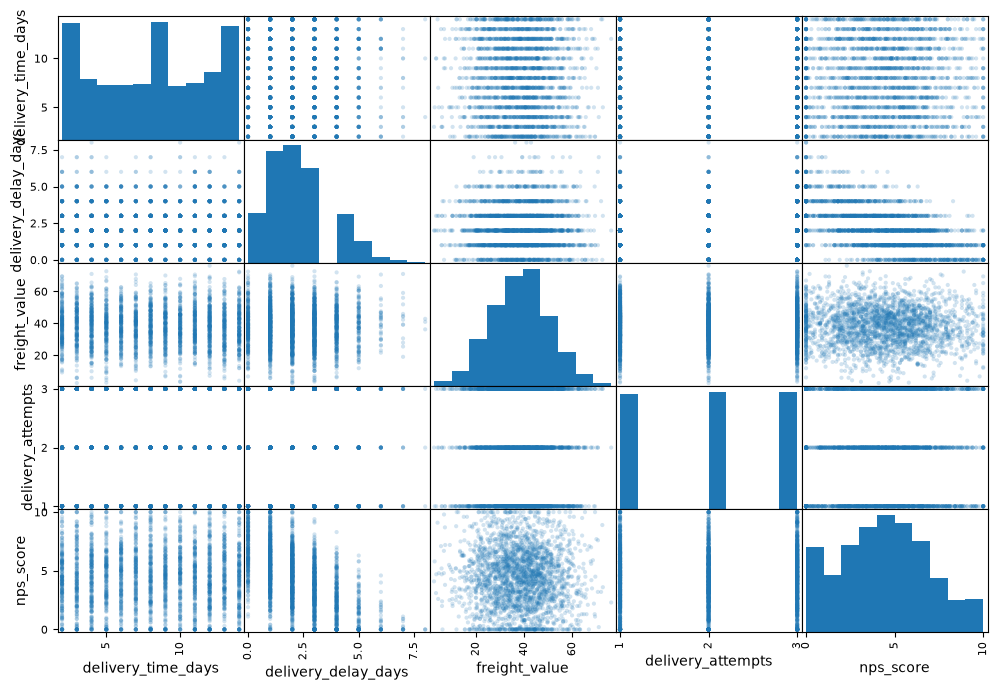

In [24]:
from pandas.plotting import scatter_matrix

attributes = ['delivery_time_days', 'delivery_delay_days', 'freight_value', 'delivery_attempts', 'nps_score']

scatter_matrix(df_classificado[attributes], figsize=(12,8), alpha=0.2)

In [25]:
df_classificado[attributes].corr()

,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,nps_score
delivery_time_days,1.000000,-0.003809,-0.021050,-0.023941,-0.001234
delivery_delay_days,-0.003809,1.000000,0.005308,0.006347,-0.599569
freight_value,-0.021050,0.005308,1.000000,0.000364,-0.039716
delivery_attempts,-0.023941,0.006347,0.000364,1.000000,0.026588
nps_score,-0.001234,-0.599569,-0.039716,0.026588,1.000000


Análise:

A correlação entre as variáveis da operação de entrega em conjunto ao nps_score mostra que não há fortes indícios de relacionamento, exceto ao analisar o delivery_delay_days (atraso) x nps_score (satisfação) com forte correlação negativa. Constatando que para alguns cenários enquanto o atraso aumenta a satisfação diminui.

Analise de Atraso x nps
                    nps_score             
                        count  mean median
delivery_delay_days                       
0                         272  6.85   6.80
1                         607  5.55   5.50
2                         638  4.59   4.65
3                         516  3.43   3.45
4                         266  2.45   2.30
5                         116  1.48   1.25
6                          33  1.06   0.70
7                          14  0.29   0.00
8                           3  0.00   0.00


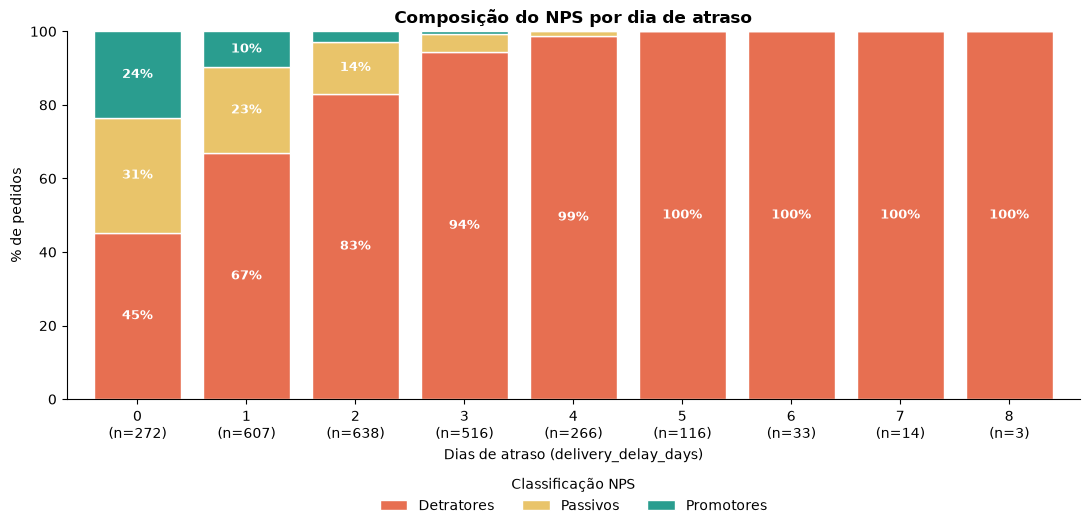

In [44]:
# Composição do NPS (Detratores/Passivos/Promotores) por dia de atraso

ORDEM_CLASSES = ["Detratores", "Passivos", "Promotores"]

# % de cada classe dentro de cada dia de atraso
composicao_atraso = (
    pd.crosstab(
        df_classificado["delivery_delay_days"],
        df_classificado["classificacao_nps"],
        normalize="index"
    )[ORDEM_CLASSES] * 100
)

# Volume de pedidos por dia, para o rótulo do eixo x
n_por_dia = df_classificado["delivery_delay_days"].value_counts().sort_index()
rotulos_x = [f"{dia}\n(n={n})" for dia, n in n_por_dia.items()]

fig, ax = plt.subplots(figsize=(11, 5.5))

composicao_atraso.plot(
    kind="bar",
    stacked=True,
    color=[CORES_NPS[c] for c in ORDEM_CLASSES],
    edgecolor="white",
    width=0.8,
    ax=ax
)

# Rótulos de % dentro dos segmentos (só os grandes o bastante para caber)
for container in ax.containers:
    rotulos = [f"{v:.0f}%" if v >= 6 else "" for v in container.datavalues]
    ax.bar_label(container, labels=rotulos, label_type="center", color="white", fontweight="bold", fontsize=9)

ax.set_xticklabels(rotulos_x, rotation=0)
ax.set_xlabel("Dias de atraso (delivery_delay_days)")
ax.set_ylabel("% de pedidos")
ax.set_ylim(0, 100)
ax.legend(title="Classificação NPS", loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)

distribuicao_atraso_nps = df_classificado[['nps_score','delivery_delay_days']].groupby('delivery_delay_days').agg(['count','mean','median']).round(2)
print(f"Analise de Atraso x nps\n{distribuicao_atraso_nps}")

plt.title("Composição do NPS por dia de atraso", fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()


C:\Users\Administrador\AppData\Local\Temp\ipykernel_28860\424616251.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(rotulos_x)


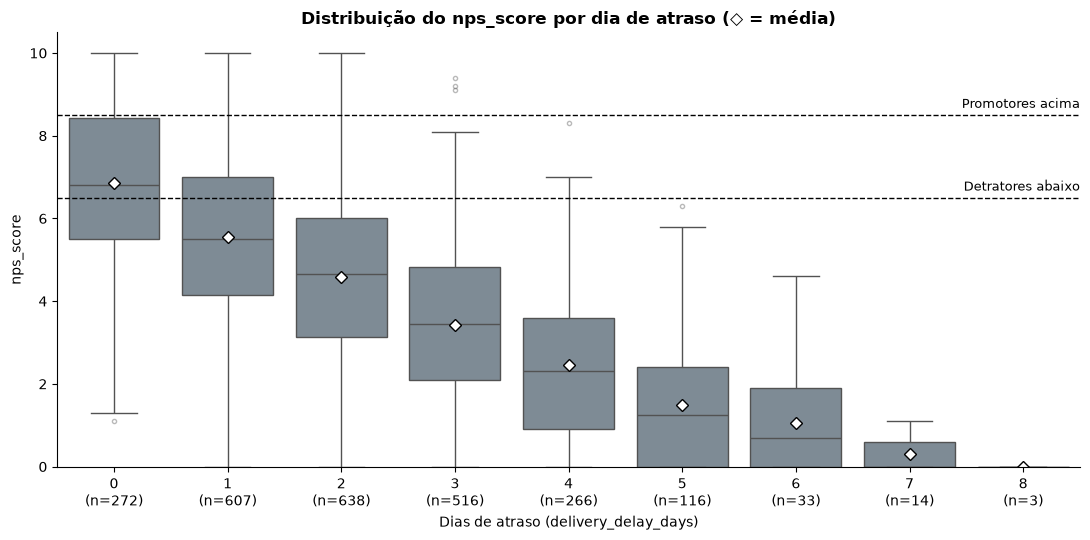

In [30]:
# Distribuição do nps_score por dia de atraso

fig, ax = plt.subplots(figsize=(11, 5.5))

sns.boxplot(
    data=df_classificado,
    x="delivery_delay_days",
    y="nps_score",
    color="#7A8B99",
    showmeans=True,
    meanprops={"marker": "D", "markerfacecolor": "white", "markeredgecolor": "black", "markersize": 6},
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
    ax=ax
)

# Faixas de classificação (mesmos cortes do pd.cut)
ax.axhline(6.5, color="black", linestyle="--", linewidth=1)
ax.axhline(8.5, color="black", linestyle="--", linewidth=1)
ax.text(ax.get_xlim()[1], 6.6, "Detratores abaixo", ha="right", va="bottom", fontsize=9)
ax.text(ax.get_xlim()[1], 8.6, "Promotores acima", ha="right", va="bottom", fontsize=9)

ax.set_xticklabels(rotulos_x)
ax.set_xlabel("Dias de atraso (delivery_delay_days)")
ax.set_ylabel("nps_score")
ax.set_ylim(0, 10.5)

plt.title("Distribuição do nps_score por dia de atraso (◇ = média)", fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()


In [ ]:
impacto_atraso = (
    df_classificado
    .groupby("faixa_atraso", observed=False)
    .agg(
        pedidos=("order_id", "count"),
        nps_medio=("nps_score", "mean"),
        percentual_detratores=(
            "classificacao_nps",
            lambda x: (x == "Detratores").mean() * 100
        )
    )
    .reindex(ORDEM_ATRASO)
    .reset_index()
)

impacto_atraso.round(2)

,faixa_atraso,pedidos,nps_medio,percentual_detratores
0,No prazo,272,6.85,36.40
1,1 dia,607,5.55,59.64
2,2 dias,638,4.59,75.39
3,3+ dias,948,2.78,93.25


Conclusão:

Podemos perceber uma queda de ~1 ponto da nota de satisfação do cliente por dia de atraso do produto. Nota-se que em 1 dia de atraso a base em média apresenta nota de 5.55 e 67% da base são Detratores. Já em 2 dias de atraso constatou uma nota de 4.59 e 83% da base são Detratores.

# Atraso x Região

* Qual o atraso médio entre regiões?
* Qual o % de atraso por região?
* Qual o tempo médio de entrega por região?

,pedidos,atraso_medio,pct_com_atraso,pct_3mais_dias,tempo_entrega_medio,nps_medio,pct_detratores
customer_region,,,,,,,
Centro-Oeste,461,2.24,88.07,40.35,7.89,4.20,80.69
Nordeste,475,2.17,89.89,38.53,8.20,4.44,79.16
Norte,502,2.15,88.05,38.05,7.73,4.38,80.88
Sudeste,514,2.21,90.86,38.33,8.21,4.39,79.96
Sul,513,2.17,87.91,37.23,8.08,4.48,79.92


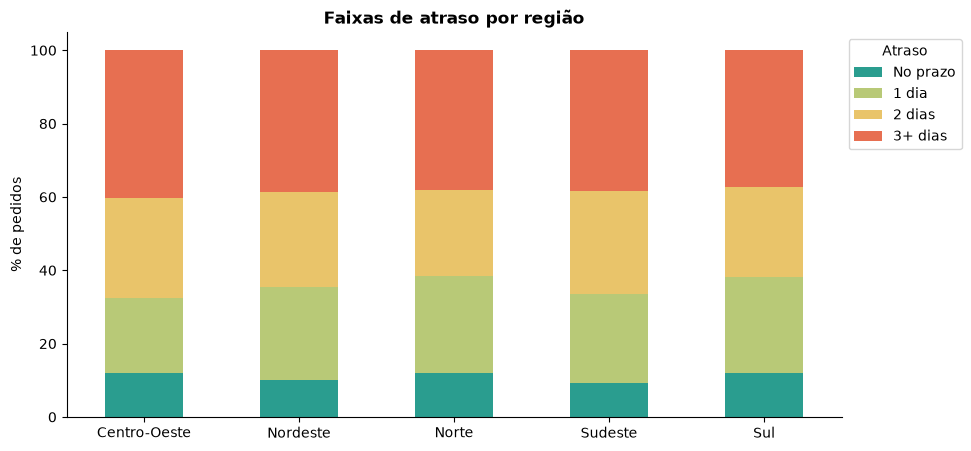

In [41]:
# Atraso por região

atraso_regiao = (
    df_classificado
    .groupby("customer_region")
    .agg(
        pedidos=("order_id", "count"),
        atraso_medio=("delivery_delay_days", "mean"),
        pct_com_atraso=("delivery_delay_days", lambda x: (x >= 1).mean() * 100),
        pct_3mais_dias=("delivery_delay_days", lambda x: (x >= 3).mean() * 100),
        tempo_entrega_medio=("delivery_time_days", "mean"),
        nps_medio=("nps_score", "mean"),
        pct_detratores=("classificacao_nps", lambda x: (x == "Detratores").mean() * 100),
    )
    .round(2)
)
display(atraso_regiao)

CORES_ATRASO = {
    "No prazo": "#2A9D8F",
    "1 dia": "#B8C977",
    "2 dias": "#E9C46A",
    "3+ dias": "#E76F51"
}

# Distribuição das faixas de atraso por região (% por linha)
ct = pd.crosstab(df_classificado["customer_region"], df_classificado["faixa_atraso"], normalize="index") * 100
ct.plot(kind="bar", stacked=True, figsize=(10, 5), color=[CORES_ATRASO[c] for c in ct.columns])
plt.title("Faixas de atraso por região", fontweight="bold")
plt.xlabel("")
plt.ylabel("% de pedidos")
plt.xticks(rotation=0)
plt.legend(title="Atraso", bbox_to_anchor=(1, 1))
sns.despine()
plt.show()

Conclusão:

O atraso é uniforme entre as regiões (~88–91% dos pedidos com atraso e atraso médio entre 2,15 e 2,24 dias). Dessa maneira, não há informações que levem a acreditar que o atraso é regional, o problema parece ser operacional.

# Atraso x Tentativas de Entrega

* Atrasos foram motivados por tentativas?
* % de atraso por tentativa?

In [4]:
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


,pedidos,atraso_medio,pct_com_atraso,pct_3mais_dias,tempo_entrega_medio,nps_medio,pct_detratores
delivery_attempts,,,,,,,
1,812,2.14,88.79,37.56,8.12,4.36,79.93
2,828,2.25,89.61,41.43,8.05,4.26,82.49
3,825,2.17,88.48,36.36,7.90,4.52,77.94


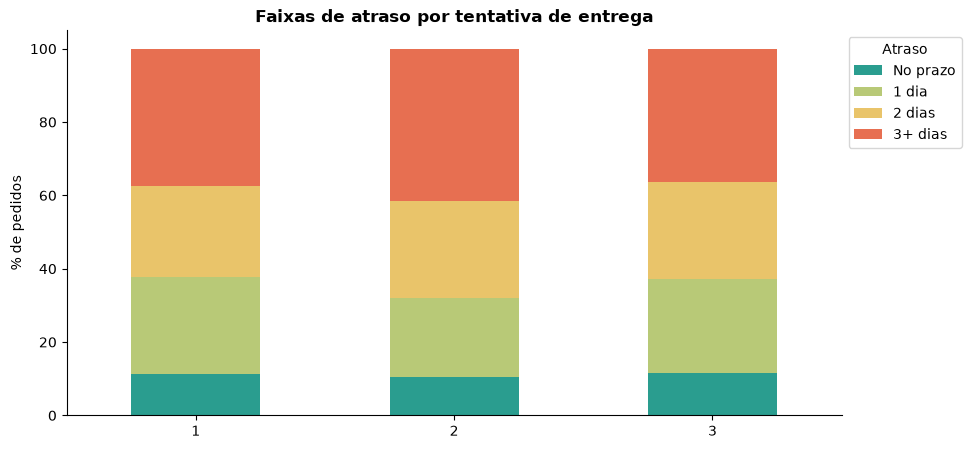

In [ ]:
atraso_tentativa = (
    df_classificado
    .groupby("delivery_attempts")
    .agg(
        pedidos=("order_id", "count"),
        atraso_medio=("delivery_delay_days", "mean"),
        pct_com_atraso=("delivery_delay_days", lambda x: (x >= 1).mean() * 100),
        pct_3mais_dias=("delivery_delay_days", lambda x: (x >= 3).mean() * 100),
        tempo_entrega_medio=("delivery_time_days", "mean"),
        nps_medio=("nps_score", "mean"),
        pct_detratores=("classificacao_nps", lambda x: (x == "Detratores").mean() * 100),
    )
    .round(2)
)
display(atraso_tentativa)

# Distribuição das faixas de atraso por região (% por linha)
ct = pd.crosstab(df_classificado["delivery_attempts"], df_classificado["faixa_atraso"], normalize="index") * 100
ct.plot(kind="bar", stacked=True, figsize=(10, 5), color=[CORES_ATRASO[c] for c in ct.columns])
plt.title("Faixas de atraso por tentativa de entrega", fontweight="bold")
plt.xlabel("")
plt.ylabel("% de pedidos")
plt.xticks(rotation=0)
plt.legend(title="Atraso", bbox_to_anchor=(1, 1))
sns.despine()
plt.show()

Conclusão:

Assim como na região, as tentativas de entrega não explicam o atraso nem modificam o impacto dele no NPS. Isso confirma o fechamento do notebook, de que para avaliar a causa são necessárias a coleta de mais informações a respeito da entrega ou averiguar outras bases que já existam.

# RESUMO

A base apresenta NPS negativo porque possui alta concentração de Detratores. Operacionalmente, atrasos são frequentes, sendo que foi percebida uma queda monotônica da satisfação por dia de atraso. Em 2 dias de atrasos foi possível notar a maior concentração de clientes na base e um nps_score médio de 4,59. Quando olhamos para faixa de atraso, especificamente 3+ dias constatou-se o pior nps_score médio e a maior proporção de detratores, mostrando que o atraso tem relação moderada com a insatisfação do cliente.

Enquanto atraso têm associação moderada com a satisfação do cliente, a região, o número de tentativas e o frete, não apresentam diferenças relevantes entre as faixas de atraso e o nps. Isso direciona a investigação para outras causas operacionais, como capacidade logística, rota, transportadora ou prazo prometido — variáveis que não estão disponíveis na base.